# Sentiment Analysis using Machine Learning

## Objective

The objective of this project is to classify tweets into positive, negative, and neutral sentiments using Natural Language Processing (NLP) and Machine Learning techniques.

Import Libraries

In [21]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import re

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

import warnings
warnings.filterwarnings("ignore")

Data Loading

In [22]:
df = pd.read_csv("Twitter_Data.csv")
df.head()

,clean_text,category
0,when modi promised “minimum government maximum...,-1.0
1,talk all the nonsense and continue all the dra...,0.0
2,what did just say vote for modi welcome bjp t...,1.0
3,asking his supporters prefix chowkidar their n...,1.0
4,answer who among these the most powerful world...,1.0


In [23]:
df.shape

(162980, 2)

In [24]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 162980 entries, 0 to 162979
Data columns (total 2 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   clean_text  162976 non-null  object 
 1   category    162973 non-null  float64
dtypes: float64(1), object(1)
memory usage: 2.5+ MB


# Data Cleaning

Before building the model, the dataset is checked for missing values and duplicate records. Cleaning improves the quality of the data and helps increase model accuracy.

In [25]:
df.isnull().sum()

,0
clean_text,4
category,7


In [26]:
df.dropna(inplace=True)

In [27]:
df.duplicated().sum()

np.int64(0)

In [28]:
df.drop_duplicates(inplace=True)

In [29]:
df.shape

(162969, 2)

In [48]:
# Convert numeric labels to sentiment names

df["category"] = df["category"].replace({
    -1: "Negative",
     0: "Neutral",
     1: "Positive"
})

# Text Preprocessing

The tweet text is converted to lowercase, and unwanted characters such as URLs, mentions, hashtags, special symbols, and extra spaces are removed. This prepares the text for feature extraction.

In [49]:
def clean_text(text):

    text = str(text).lower()

    text = re.sub(r"http\S+", "", text)

    text = re.sub(r"@\w+", "", text)

    text = re.sub(r"#", "", text)

    text = re.sub(r"[^a-zA-Z ]", "", text)

    text = re.sub(r"\s+", " ", text)

    return text

df["clean_text"] = df["clean_text"].apply(clean_text)

# Sentiment Analysis

The sentiment labels are analyzed to understand the distribution of positive, negative, and neutral tweets in the dataset.

In [50]:
df["category"].value_counts()

,count
category,
Positive,72249
Neutral,55211
Negative,35509


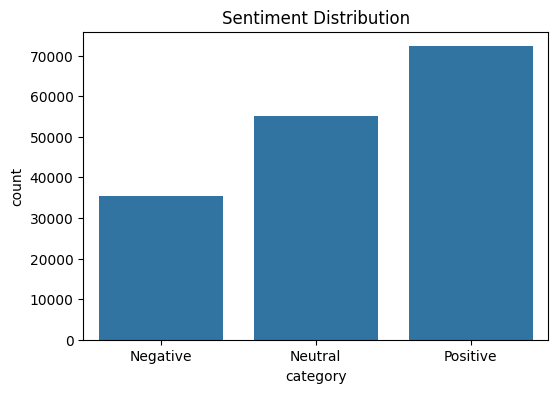

In [51]:
plt.figure(figsize=(6,4))

sns.countplot(data=df,x="category")

plt.title("Sentiment Distribution")

plt.show()

# Natural Language Processing (NLP)
## Feature Engineering

Feature engineering improves model performance by transforming raw text into meaningful numerical representations. TF-IDF assigns importance to words based on their frequency and relevance.

Machine learning algorithms cannot directly process text data. Therefore, the tweet text is converted into numerical features using the TF-IDF (Term Frequency-Inverse Document Frequency) technique.

In [52]:
X = df["clean_text"]

y = df["category"]

In [53]:
vectorizer = TfidfVectorizer(
    stop_words="english",
    max_features=5000,
    ngram_range=(1,2)
)

X_vector = vectorizer.fit_transform(X)

##  Train-Test Split

The dataset is divided into training and testing sets. The training data is used to build the model, while the testing data is used to evaluate its performance on unseen examples.

In [54]:
X_train, X_test, y_train, y_test = train_test_split(
    X_vector,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Machine Learning Algorithm

The Linear Support Vector Classifier (LinearSVC) is used for sentiment classification. It is an efficient algorithm for text classification tasks and provides high accuracy for sentiment prediction.


In [55]:
model = LinearSVC()

model.fit(X_train,y_train)

LinearSVC()

# Model Prediction

The trained model predicts the sentiment labels for the testing dataset. These predictions are later compared with the actual labels to evaluate model performance.

In [56]:
prediction = model.predict(X_test)

# Model Evaluation

The model is evaluated using accuracy score, classification report, and confusion matrix. These metrics measure how well the model classifies sentiments into their correct categories.

In [57]:
print("Accuracy Score")

print(accuracy_score(y_test,prediction))

Accuracy Score
0.850524636436154


Classification Report

In [58]:
print(classification_report(y_test,prediction))

              precision    recall  f1-score   support

    Negative       0.86      0.74      0.79      7102
     Neutral       0.79      0.96      0.87     11042
    Positive       0.91      0.82      0.86     14450

    accuracy                           0.85     32594
   macro avg       0.85      0.84      0.84     32594
weighted avg       0.86      0.85      0.85     32594



Confusion Matrix

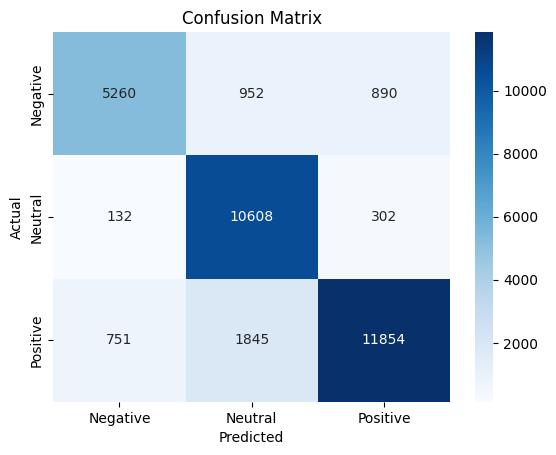

In [59]:
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Negative", "Neutral", "Positive"],
    yticklabels=["Negative", "Neutral", "Positive"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

Sentiment Count

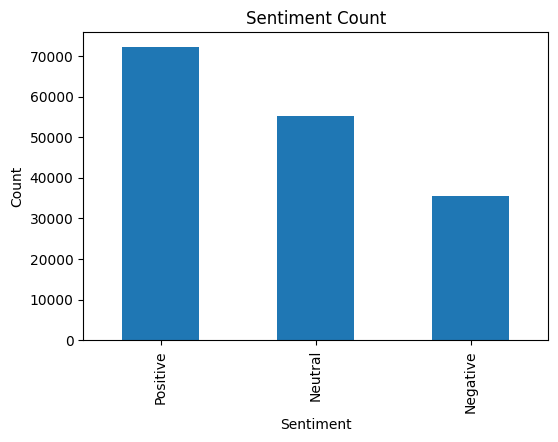

In [60]:
plt.figure(figsize=(6,4))

df["category"].value_counts().plot(kind="bar")

plt.title("Sentiment Count")

plt.xlabel("Sentiment")

plt.ylabel("Count")

plt.show()

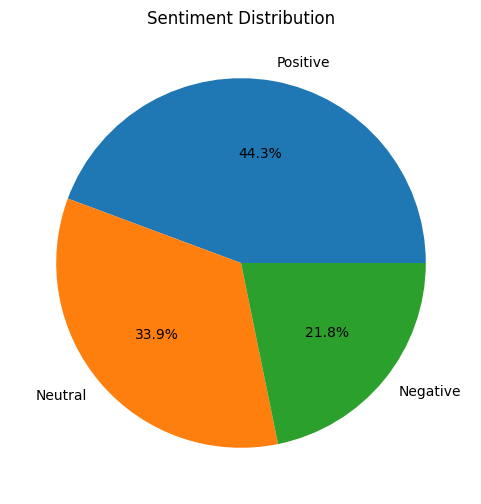

In [61]:
plt.figure(figsize=(6,6))

df["category"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%"
)

plt.ylabel("")

plt.title("Sentiment Distribution")

plt.show()

Tweet Length Distribution

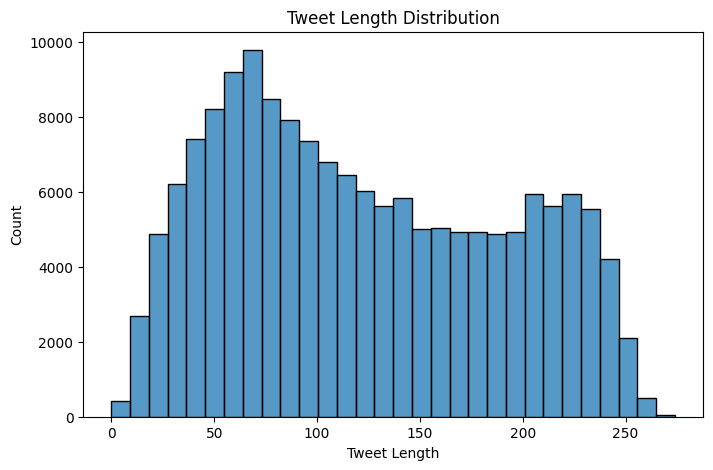

In [62]:
df["Length"] = df["clean_text"].apply(len)

plt.figure(figsize=(8,5))

sns.histplot(df["Length"],bins=30)

plt.title("Tweet Length Distribution")

plt.xlabel("Tweet Length")

plt.ylabel("Count")

plt.show()

Correlation Heatmap

# Machine Learning Algorithm

The dataset is divided into training and testing sets. A Multinomial Naive Bayes classifier is trained to classify tweet sentiments into different categories.

In [64]:
X_train, X_test, y_train, y_test = train_test_split(
    X_vector,
    y,
    test_size=0.2,
    random_state=42
)

In [65]:
model = MultinomialNB()

model.fit(X_train,y_train)

MultinomialNB()

In [66]:
prediction = model.predict(X_test)